# Gradient Descent and Optimization Geometry

## Introduction

Gradient descent is a first-order optimization method used to minimize a scalar objective function:

$$
\mathcal{L}(\theta)
$$

where $ \theta \in \mathbb{R}^n $ represents the model parameters.  
Training a machine learning model can therefore be interpreted as solving:

$$
\min_{\theta} \mathcal{L}(\theta)
$$

From a geometric perspective, the loss defines a surface over parameter space. The gradient,

$$
\nabla \mathcal{L}(\theta),
$$

is a vector pointing in the direction of steepest increase of the function and is orthogonal to the level sets of the loss. Gradient descent updates parameters by moving in the opposite direction:

$$
\theta_{t+1}
=
\theta_t - \eta \nabla \mathcal{L}(\theta_t),
$$

where $ \eta > 0 $ is the learning rate, which scales the step taken along the negative gradient.

The local behavior of gradient descent is governed by the curvature of the surface, encoded by the Hessian matrix:

$$
H = \nabla^2 \mathcal{L}(\theta).
$$

The eigenvalues of the Hessian determine how steeply the loss curves along different directions, directly influencing stability, convergence speed, and oscillatory behavior.

---

## Example: A Convex Quadratic Objective

To make these geometric principles explicit, we will study the convex quadratic function:

$$
L(x, y) = x^2 + y^2.
$$

This function provides a well-conditioned optimization landscape with circular level sets and constant curvature. It allows us to:

- Derive the gradient analytically,
- Analyze stability conditions on the learning rate,
- Visualize the optimization trajectory,
- Connect curvature, eigenvalues, and convergence behavior.

Although simple, this example captures the essential geometric structure underlying gradient-based optimization in higher-dimensional machine learning models.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike

def convex_quadratic_loss(x, y) -> float:
    return x**2 + y**2

def gradient(x: float, y: float):
    return np.array([[2*x], [2*y]]).reshape(2, 1)

def gradient_descent_step(x, y, learning_rate=.01):
    g = gradient(x, y)
    x_new = x - learning_rate  * g[0]
    y_new = y - learning_rate  * g[1]
    return x_new, y_new

x = 5
y = 2
epochs = 100
trajectory = np.empty((2, 0))

for e in range(epochs):
    point = np.array([[x], [y]]).reshape(2, 1)
    trajectory = np.hstack((trajectory, point))
    
    x_new, y_new = gradient_descent_step(x, y)
    x = x_new.reshape(-1, 1)
    y = y_new.reshape(-1, 1)
    

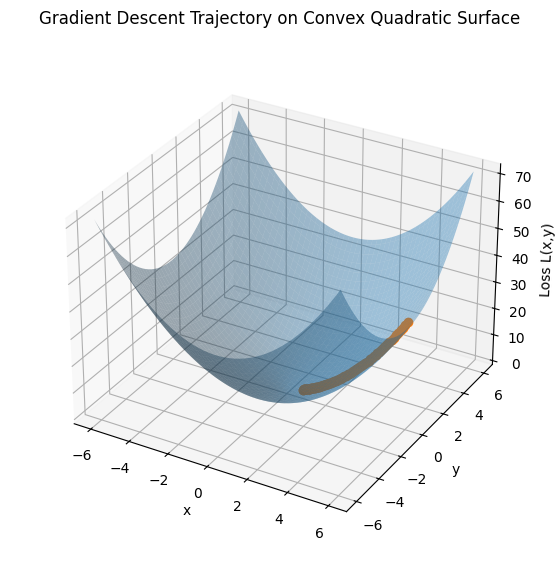

In [25]:
x_vals = np.linspace(-6, 6, 100)
y_vals = np.linspace(-6, 6, 100)

X, Y = np.meshgrid(x_vals, y_vals)
Z = convex_quadratic_loss(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.4)

traj_z = convex_quadratic_loss(trajectory[0, :], trajectory[1, :])
ax.plot(trajectory[0, :], trajectory[1, :], traj_z, linewidth=3, marker='o')

ax.set_box_aspect(aspect=None, zoom=0.9)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Loss L(x,y)")
ax.set_title("Gradient Descent Trajectory on Convex Quadratic Surface")

plt.show()

In [ ]:
g

In [ ]:
grad_hist

In [ ]:
grad_hist.reshape((2, len(grad_hist)))